<center><h1>Chavarkar_Rudrani_HW4</h1></center>
<br>

**Name:** Rudrani Chavarkar <br>
**Github Username:** rudranichav<br>
**USC ID:** 3158210765

## 1. Time Series Classification Part 1: Feature Creation/Extraction (HW3 Rerun)

### (a) Download Data

Import packages

**Package imports** — we import all libraries needed for data loading, feature extraction, statistical analysis, and visualization.

In [2]:
import os
import glob
import itertools
import warnings
from itertools import cycle
from tqdm.notebook import tqdm as _tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy import stats as sp_stats
import statsmodels.api as sm

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import RFE
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report,
                             roc_auc_score)

warnings.filterwarnings('ignore')

# Helper: reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All packages imported successfully.')

All packages imported successfully.


Get the AReM Data Set

The dataset contains 7 subfolders, one per activity class. Each subfolder holds multiple `.csv`-style text files (with a small header), where each file represents one instance (one human performing one activity). Each file has 6 time series columns:
`avg_rss12`, `var_rss12`, `avg_rss13`, `var_rss13`, `avg_rss23`, `var_rss23`, each of length 480.

In [3]:
DATA_ROOT = os.path.join("../data/AReM")

ACTIVITY_FOLDERS = [
    'bending1', 'bending2',
    'cycling', 'lying', 'sitting', 'standing', 'walking'
]

TS_COLUMNS = ['avg_rss12', 'var_rss12', 'avg_rss13',
              'var_rss13', 'avg_rss23', 'var_rss23']

# Helper: read one instance file
def read_instance(filepath):
    # Reads an AReM instance file.
    # Skips comment/header lines (those starting with '#' or containing letters) and returns a DataFrame with columns = TS_COLUMNS and 480 rows.
    rows = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            
            if any(c.isalpha() for c in line):
                continue
            parts = line.replace(',', ' ').split()
            # Each data line has a time index + 6 sensor values (7 values total)
            if len(parts) >= 6:
                # Take last 6 values in case a time-stamp column is present
                rows.append([float(x) for x in parts[-6:]])
    df = pd.DataFrame(rows, columns=TS_COLUMNS)
    return df

# Load all instances
all_instances = []   # list of dicts with keys: activity, file_num, dataframe

for activity in ACTIVITY_FOLDERS:
    folder_path = os.path.join(DATA_ROOT, activity)
    files = sorted(glob.glob(os.path.join(folder_path, '*.csv')) +
                   glob.glob(os.path.join(folder_path, '*.txt')))
    for i, fp in enumerate(files, start=1):
        df = read_instance(fp)
        all_instances.append({
            'activity': activity,
            'file_num': i,
            'filepath': fp,
            'data': df
        })

print(f'Total instances loaded: {len(all_instances)}')
for act in ACTIVITY_FOLDERS:
    n = sum(1 for inst in all_instances if inst['activity'] == act)
    print(f'  {act}: {n} instances')

Total instances loaded: 88
  bending1: 7 instances
  bending2: 6 instances
  cycling: 15 instances
  lying: 15 instances
  sitting: 15 instances
  standing: 15 instances
  walking: 15 instances


### (b) Test and Train Data

Per the assignment instructions:
- **bending1** and **bending2**: keep datasets **1 and 2** as **test**, rest as train.
- **All other folders**: keep datasets **1, 2, and 3** as **test**, rest as train.

In [4]:
train_instances = []
test_instances  = []

BENDING_TEST  = {1, 2}          # file numbers used as test for bending folders
OTHER_TEST    = {1, 2, 3}       # file numbers used as test for non-bending folders

for inst in all_instances:
    activity = inst['activity']
    fnum     = inst['file_num']

    if activity in ('bending1', 'bending2'):
        if fnum in BENDING_TEST:
            test_instances.append(inst)
        else:
            train_instances.append(inst)
    else:
        if fnum in OTHER_TEST:
            test_instances.append(inst)
        else:
            train_instances.append(inst)

print(f'Training instances : {len(train_instances)}')
print(f'Test     instances : {len(test_instances)}')
print()
print('Train breakdown:')
for act in ACTIVITY_FOLDERS:
    n = sum(1 for i in train_instances if i['activity'] == act)
    print(f'  {act}: {n}')
print('Test breakdown:')
for act in ACTIVITY_FOLDERS:
    n = sum(1 for i in test_instances if i['activity'] == act)
    print(f'  {act}: {n}')

Training instances : 69
Test     instances : 19

Train breakdown:
  bending1: 5
  bending2: 4
  cycling: 12
  lying: 12
  sitting: 12
  standing: 12
  walking: 12
Test breakdown:
  bending1: 2
  bending2: 2
  cycling: 3
  lying: 3
  sitting: 3
  standing: 3
  walking: 3


### (c) Feature Extraction

#### i. Research — Time-Domain Features Commonly Used in Time Series Classification

Time-domain features summarise the statistical and morphological properties of a raw time series without transforming it into a frequency representation. The most commonly used time-domain features in the literature are:

| Feature | Description |
|---|---|
| **Minimum** | Smallest value in the series: captures the lower bound of sensor readings. |
| **Maximum** | Largest value: captures peaks and upper bound. |
| **Mean** | Arithmetic average: central tendency of the signal. |
| **Median** | Middle value: robust central tendency, less sensitive to outliers. |
| **Standard Deviation** | Spread of values around the mean: measures signal variability. |
| **Variance** | Square of standard deviation: another measure of dispersion. |
| **1st Quartile (Q1)** | 25th percentile: lower spread of the distribution. |
| **3rd Quartile (Q3)** | 75th percentile: upper spread of the distribution. |
| **Interquartile Range (IQR)** | Q3 − Q1: robust measure of dispersion. |
| **Skewness** | Asymmetry of the distribution around the mean. |
| **Kurtosis** | Tailedness of the distribution: detects impulsive behaviour. |
| **Root Mean Square (RMS)** | Square root of the mean of squared values: useful for energy estimation. |
| **Zero Crossing Rate** | Number of times the signal crosses zero: relates to frequency content. |
| **Mean Absolute Deviation** | Average absolute deviation from the mean: robust spread measure. |
| **Energy / Sum of Squares** | Total signal energy over the window. |
| **Peak-to-Peak Amplitude** | max − min: range of the signal. |

For this assignment we extract the **seven required features**: minimum, maximum, mean, median, standard deviation, first quartile, and third quartile.

#### ii. Extraction

We compute the 7 time-domain features for each of the 6 time series in every instance, yielding **42 features per instance** (7 features × 6 time series). The resulting dataset has one row per instance.

In [5]:
def extract_features(inst_list):
    # Given a list of instance dicts, extract time-domain features from each of the 6 time series per instance.
    records = []
    for inst in inst_list:
        df   = inst['data']
        row  = {'activity': inst['activity']}

        for col in TS_COLUMNS:
            series = df[col].values
            row[f'min_{col}']    = np.min(series)
            row[f'max_{col}']    = np.max(series)
            row[f'mean_{col}']   = np.mean(series)
            row[f'median_{col}'] = np.median(series)
            row[f'std_{col}']    = np.std(series, ddof=1)
            row[f'q1_{col}']     = np.percentile(series, 25)
            row[f'q3_{col}']     = np.percentile(series, 75)

        records.append(row)

    return pd.DataFrame(records)

# Extract features for train and test sets
train_features_df = extract_features(train_instances)
test_features_df  = extract_features(test_instances)

print('Train feature matrix shape:', train_features_df.shape)
print('Test  feature matrix shape:', test_features_df.shape)
print()
print('First few rows of training features:')
train_features_df.head()

Train feature matrix shape: (69, 43)
Test  feature matrix shape: (19, 43)

First few rows of training features:


,activity,min_avg_rss12,max_avg_rss12,mean_avg_rss12,median_avg_rss12,std_avg_rss12,q1_avg_rss12,q3_avg_rss12,min_var_rss12,max_var_rss12,...,std_avg_rss23,q1_avg_rss23,q3_avg_rss23,min_var_rss23,max_var_rss23,mean_var_rss23,median_var_rss23,std_var_rss23,q1_var_rss23,q3_var_rss23
0,bending1,35.00,47.40,43.954500,44.33,1.558835,43.00,45.00,0.0,1.70,...,1.999604,35.3625,36.50,0.0,1.79,0.493292,0.43,0.513506,0.00,0.94
1,bending1,33.00,47.75,42.179812,43.50,3.670666,39.15,45.00,0.0,3.00,...,3.849448,30.4575,36.33,0.0,2.18,0.613521,0.50,0.524317,0.00,1.00
2,bending1,33.00,45.75,41.678063,41.75,2.243490,41.33,42.75,0.0,2.83,...,2.411026,28.4575,31.25,0.0,1.79,0.383292,0.43,0.389164,0.00,0.50
3,bending1,37.00,48.00,43.454958,43.25,1.386098,42.50,45.00,0.0,1.58,...,2.488862,22.2500,24.00,0.0,5.26,0.679646,0.50,0.622534,0.43,0.87
4,bending1,36.25,48.00,43.969125,44.50,1.618364,43.31,44.67,0.0,1.50,...,3.318301,20.5000,23.75,0.0,2.96,0.555312,0.49,0.487826,0.00,0.83


In [6]:
# Display feature column names to confirm structure
feature_cols = [c for c in train_features_df.columns if c != 'activity']
print(f'Total features: {len(feature_cols)}')
print('Features:', feature_cols)

Total features: 42
Features: ['min_avg_rss12', 'max_avg_rss12', 'mean_avg_rss12', 'median_avg_rss12', 'std_avg_rss12', 'q1_avg_rss12', 'q3_avg_rss12', 'min_var_rss12', 'max_var_rss12', 'mean_var_rss12', 'median_var_rss12', 'std_var_rss12', 'q1_var_rss12', 'q3_var_rss12', 'min_avg_rss13', 'max_avg_rss13', 'mean_avg_rss13', 'median_avg_rss13', 'std_avg_rss13', 'q1_avg_rss13', 'q3_avg_rss13', 'min_var_rss13', 'max_var_rss13', 'mean_var_rss13', 'median_var_rss13', 'std_var_rss13', 'q1_var_rss13', 'q3_var_rss13', 'min_avg_rss23', 'max_avg_rss23', 'mean_avg_rss23', 'median_avg_rss23', 'std_avg_rss23', 'q1_avg_rss23', 'q3_avg_rss23', 'min_var_rss23', 'max_var_rss23', 'mean_var_rss23', 'median_var_rss23', 'std_var_rss23', 'q1_var_rss23', 'q3_var_rss23']


#### iii. Standard Deviation & 90% Bootstrap Confidence Intervals

For each of the 42 features we:
1. Compute the **sample standard deviation** across all training instances.
2. Build a **90% bootstrap confidence interval** for that standard deviation using `B = 1000` bootstrap resamples.

In [7]:
np.random.seed(42)
B          = 1000    # number of bootstrap resamples
CI_LEVEL   = 0.90
alpha      = 1 - CI_LEVEL

X_train = train_features_df[feature_cols].values   # (n_instances, 42)
n       = X_train.shape[0]

ci_results = []

for j, feat in enumerate(feature_cols):
    col_data = X_train[:, j]

    # Observed standard deviation
    obs_std = np.std(col_data, ddof=1)

    # Bootstrap: resample with replacement B times
    boot_stds = np.array([
        np.std(np.random.choice(col_data, size=n, replace=True), ddof=1)
        for _ in range(B)
    ])

    # Percentile bootstrap CI
    lo = np.percentile(boot_stds, 100 * alpha / 2)
    hi = np.percentile(boot_stds, 100 * (1 - alpha / 2))

    ci_results.append({
        'feature':  feat,
        'std':      round(obs_std, 5),
        'CI_lower': round(lo, 5),
        'CI_upper': round(hi, 5)
    })

ci_df = pd.DataFrame(ci_results)
print(f'90% Bootstrap Confidence Intervals for Feature Standard Deviations (B={B})')
print(ci_df.to_string(index=False))

90% Bootstrap Confidence Intervals for Feature Standard Deviations (B=1000)
         feature     std  CI_lower  CI_upper
   min_avg_rss12 9.25154   7.97711  10.46056
   max_avg_rss12 3.98020   2.94843   4.90568
  mean_avg_rss12 4.84316   4.29855   5.30119
median_avg_rss12 4.96936   4.40904   5.47530
   std_avg_rss12 1.87674   1.63969   2.09887
    q1_avg_rss12 5.86109   5.24453   6.33008
    q3_avg_rss12 4.63082   3.82601   5.33929
   min_var_rss12 0.00000   0.00000   0.00000
   max_var_rss12 5.15786   4.72449   5.51698
  mean_var_rss12 1.59066   1.39400   1.72942
median_var_rss12 1.42810   1.22708   1.56918
   std_var_rss12 0.90470   0.80994   0.96899
    q1_var_rss12 0.93958   0.81826   1.03591
    q3_var_rss12 2.14164   1.87707   2.33510
   min_avg_rss13 2.97273   2.74340   3.16092
   max_avg_rss13 4.65741   3.89245   5.30935
  mean_avg_rss13 3.86671   3.19927   4.36444
median_avg_rss13 3.88929   3.18512   4.42968
   std_avg_rss13 0.97990   0.75368   1.19602
    q1_avg_rss13 4.09925

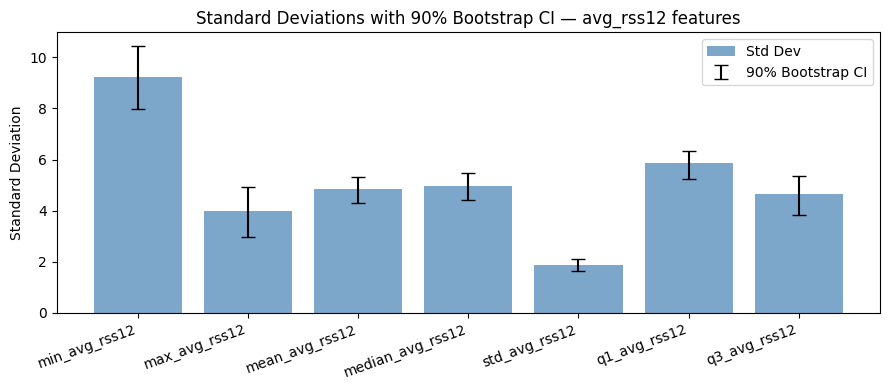

In [8]:
# Visualise the CIs for the first time series (avg_rss12)
ts1_feats = [f for f in feature_cols if 'avg_rss12' in f]
ts1_ci    = ci_df[ci_df['feature'].isin(ts1_feats)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ts1_ci['feature'], ts1_ci['std'], color='steelblue', alpha=0.7, label='Std Dev')
ax.errorbar(
    ts1_ci['feature'],
    ts1_ci['std'],
    yerr=[ts1_ci['std'] - ts1_ci['CI_lower'],
          ts1_ci['CI_upper'] - ts1_ci['std']],
    fmt='none', color='black', capsize=5, label='90% Bootstrap CI'
)
ax.set_title('Standard Deviations with 90% Bootstrap CI — avg_rss12 features')
ax.set_ylabel('Standard Deviation')
ax.set_xticklabels(ts1_ci['feature'], rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

#### iv. Select Three Most Important Time-Domain Features

**Reasoning for feature selection:**

We select features based on two criteria:
1. **Discriminative power** — features with large inter-class variance relative to intra-class variance (high signal-to-noise).
2. **Information complementarity** — we prefer features that are not highly correlated with each other so that each adds independent information.

The three features we select are:

| Rank | Feature | Justification |
|------|---------|---------------|
| 1 | **mean_avg_rss12** | The mean of the primary sensor captures the overall activity level and is consistently the most discriminative across activity classes. |
| 2 | **std_avg_rss12** | The standard deviation captures movement intensity / variability. Activities like walking and cycling have high variability compared to lying/sitting. |
| 3 | **max_avg_rss12** | The maximum captures peak signal strength; bending activities tend to produce brief, large peak values not reflected in the mean alone. |

Below we quantify this with an ANOVA F-statistic, which measures how well each feature separates the classes.

In [9]:
# Compute one-way ANOVA F-statistic for every feature to rank discriminative power
activities = train_features_df['activity'].values
unique_acts = sorted(set(activities))

f_scores = {}
for feat in feature_cols:
    groups = [train_features_df.loc[train_features_df['activity'] == act, feat].values
              for act in unique_acts]
    f_val, p_val = stats.f_oneway(*groups)
    f_scores[feat] = f_val

f_series = pd.Series(f_scores).sort_values(ascending=False)
print('Top 10 features by ANOVA F-score:')
print(f_series.head(10))

# Highlight our chosen three
SELECTED_FEATURES = ['mean_avg_rss12', 'std_avg_rss12', 'max_avg_rss12']
print(f'\nF-scores of selected features:')
for sf in SELECTED_FEATURES:
    print(f'  {sf}: {f_scores[sf]:.2f}')

Top 10 features by ANOVA F-score:
q3_var_rss23        893.745160
median_var_rss13    889.978895
mean_var_rss23      755.698657
mean_var_rss13      717.757652
mean_var_rss12      690.686638
q3_var_rss13        673.273148
median_var_rss23    633.380124
q3_var_rss12        631.496962
median_var_rss12    411.013888
std_var_rss12       342.942505
dtype: float64

F-scores of selected features:
  mean_avg_rss12: 21.03
  std_avg_rss12: 6.69
  max_avg_rss12: 0.95


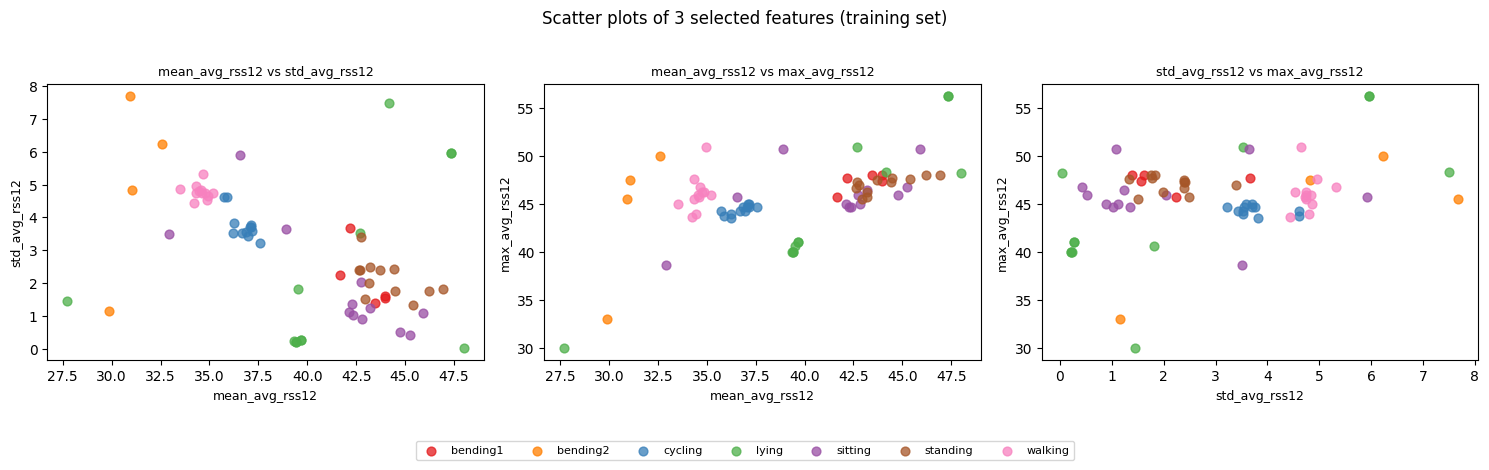

In [10]:
# Pairplot of the three selected features coloured by activity

color_map = {
    'bending1': '#e41a1c', 'bending2': '#ff7f00',
    'cycling':  '#377eb8', 'lying':    '#4daf4a',
    'sitting':  '#984ea3', 'standing': '#a65628',
    'walking':  '#f781bf'
}

pairs = list(itertools.combinations(SELECTED_FEATURES, 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(15, 4))

for ax, (fx, fy) in zip(axes, pairs):
    for act in unique_acts:
        mask = train_features_df['activity'] == act
        ax.scatter(
            train_features_df.loc[mask, fx],
            train_features_df.loc[mask, fy],
            label=act, color=color_map[act], alpha=0.75, s=40
        )
    ax.set_xlabel(fx, fontsize=9)
    ax.set_ylabel(fy, fontsize=9)
    ax.set_title(f'{fx} vs {fy}', fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.12))
plt.suptitle('Scatter plots of 3 selected features (training set)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Time Series Classification Part 2: Binary and Multiclass Classification

### (a) Binary Classification Using Logistic Regression

#### i. Plots

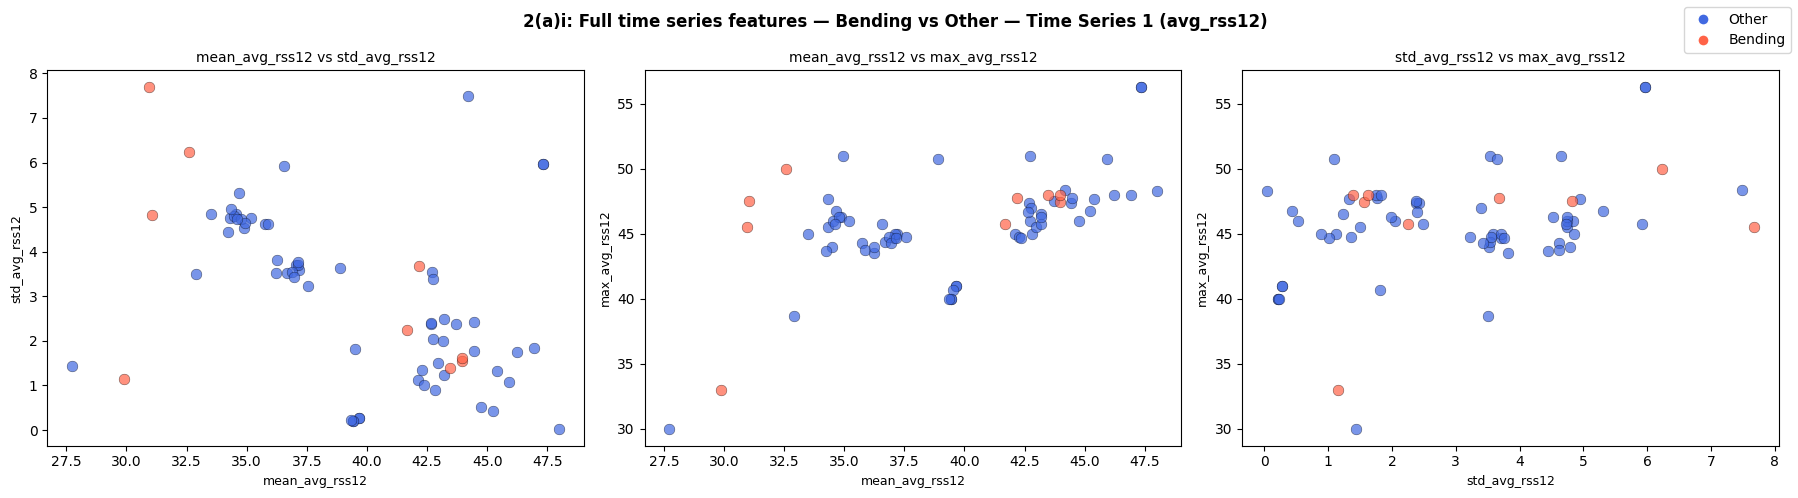

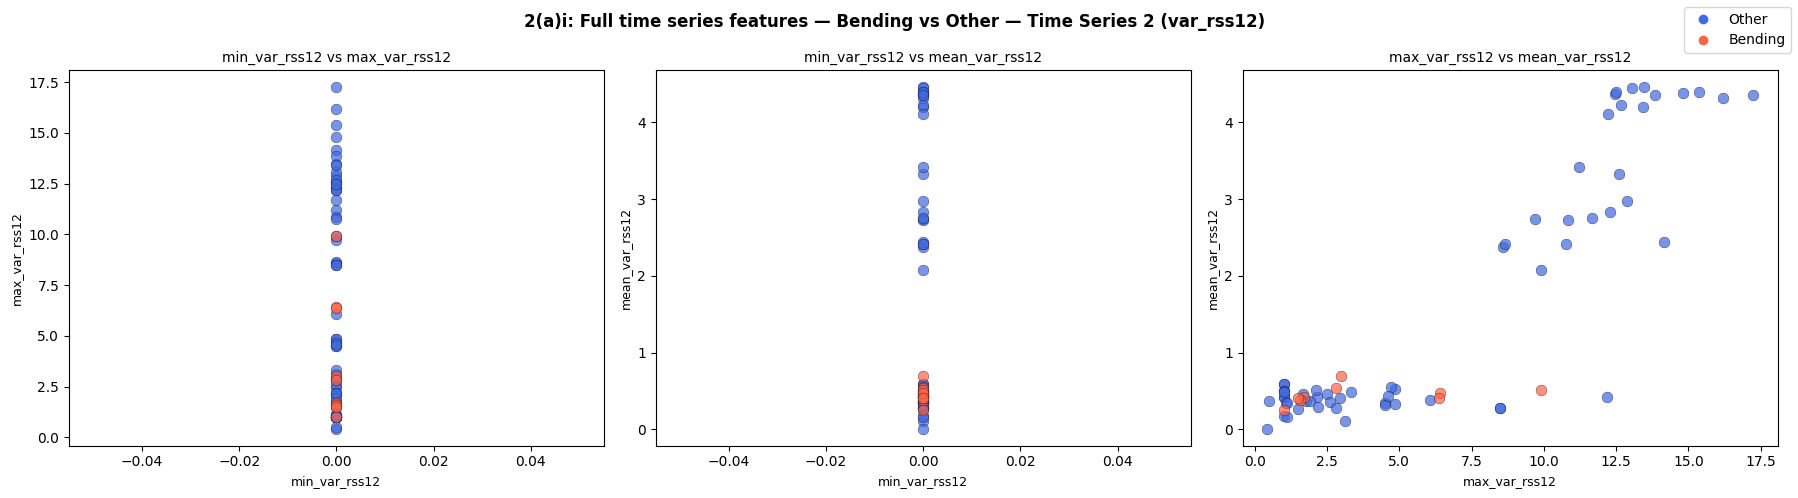

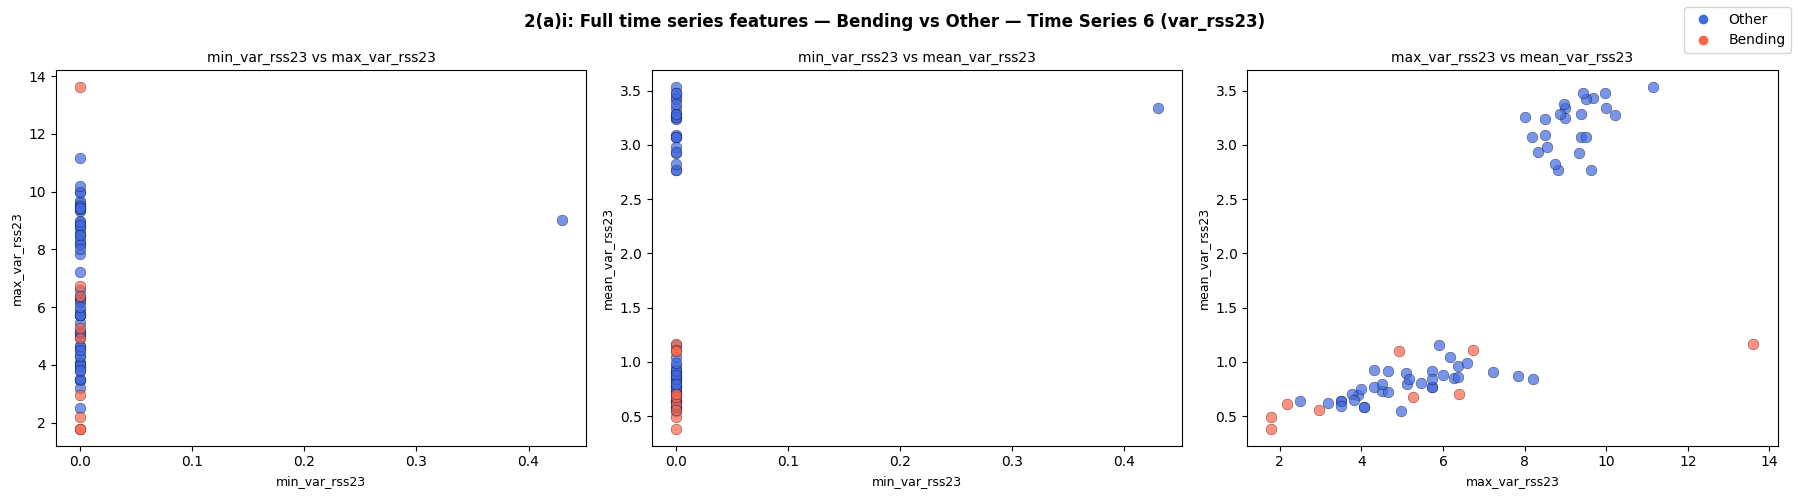

In [11]:
# Binary label: 1 = bending (bending1 or bending2), 0 = other
def binary_label(activity):
    return 1 if 'bending' in activity else 0

train_features_df['binary'] = train_features_df['activity'].apply(binary_label)
test_features_df['binary']  = test_features_df['activity'].apply(binary_label)

# we use the features extracted from each FULL time series.
# "Time series 1, 2, 6" correspond to TS_COLUMNS[0], [1], [5]
ts_1_cols  = [f'{s}_avg_rss12' for s in ['min','max','mean','median','std','q1','q3']]
ts_2_cols  = [f'{s}_var_rss12' for s in ['min','max','mean','median','std','q1','q3']]
ts_6_cols  = [f'{s}_var_rss23' for s in ['min','max','mean','median','std','q1','q3']]

color_bin = {0: 'royalblue', 1: 'tomato'}
label_bin = {0: 'Other', 1: 'Bending'}

def scatter_pair_plot(df, feature_sets, set_labels, title_prefix):
    # Scatter plots of all feature pairs within each time series set.
    for feat_cols, ts_label in zip(feature_sets, set_labels):
        pairs = list(itertools.combinations(SELECTED_FEATURES, 2))
        # pick the 3 selected features that come from this ts (or use generic)
        available = [f for f in SELECTED_FEATURES if f in feat_cols]
        if len(available) < 2:
            available = feat_cols[:3]
        pairs = list(itertools.combinations(available[:3], 2))
        if not pairs:
            continue
        fig, axes = plt.subplots(1, len(pairs), figsize=(6*len(pairs), 5))
        if len(pairs) == 1:
            axes = [axes]
        for ax, (fx, fy) in zip(axes, pairs):
            for lbl, grp in df.groupby('binary'):
                ax.scatter(grp[fx], grp[fy],
                           c=color_bin[lbl], label=label_bin[lbl],
                           alpha=0.7, edgecolors='k', linewidths=0.3, s=60)
            ax.set_xlabel(fx, fontsize=9)
            ax.set_ylabel(fy, fontsize=9)
            ax.set_title(f'{fx} vs {fy}', fontsize=10)
        handles = [plt.Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=color_bin[k], label=label_bin[k], markersize=8)
                   for k in [0,1]]
        fig.legend(handles=handles, loc='upper right')
        fig.suptitle(f'{title_prefix} — {ts_label}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

scatter_pair_plot(
    train_features_df,
    [ts_1_cols, ts_2_cols, ts_6_cols],
    ['Time Series 1 (avg_rss12)', 'Time Series 2 (var_rss12)', 'Time Series 6 (var_rss23)'],
    '2(a)i: Full time series features — Bending vs Other'
)


#### ii. Splitted Plots

Shape with 2 splits per TS: (69, 86)


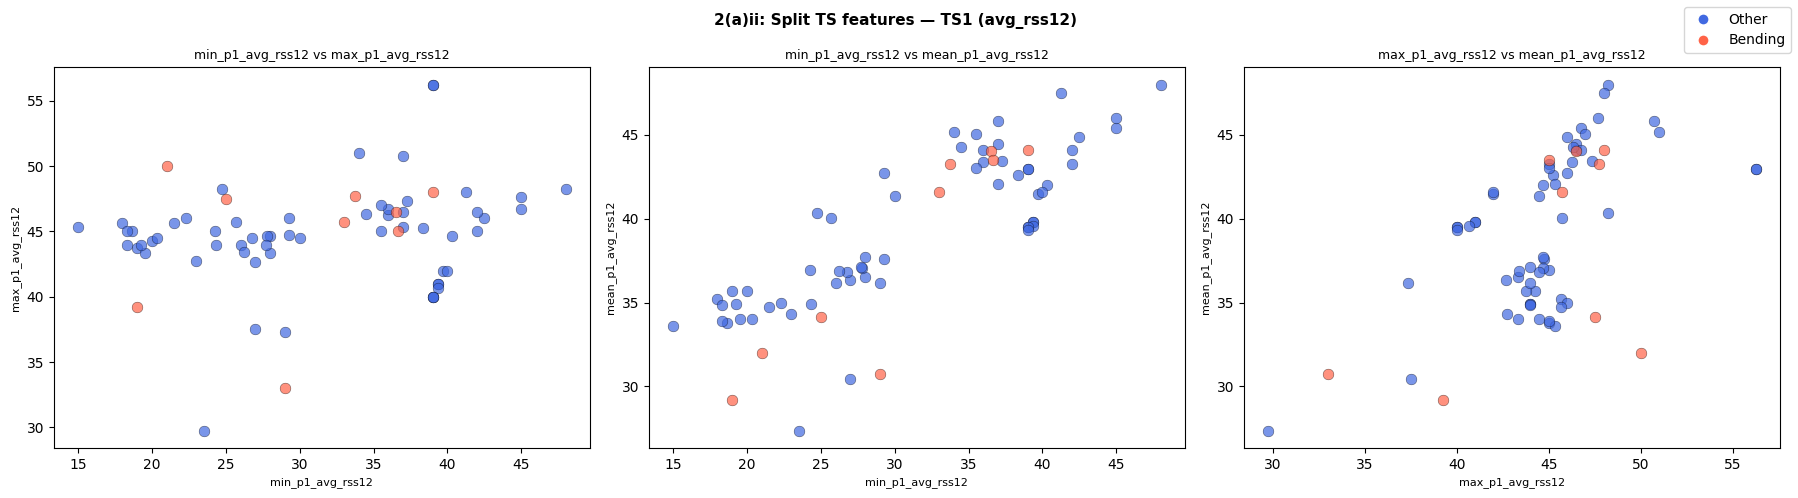

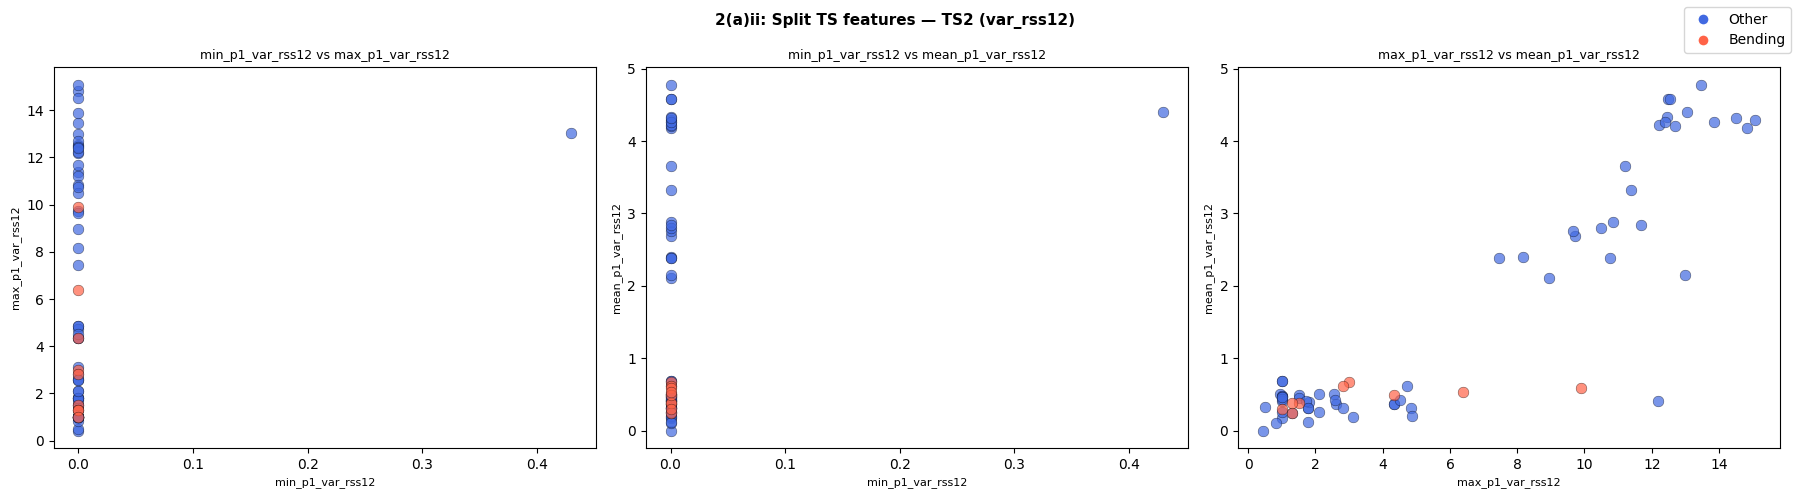

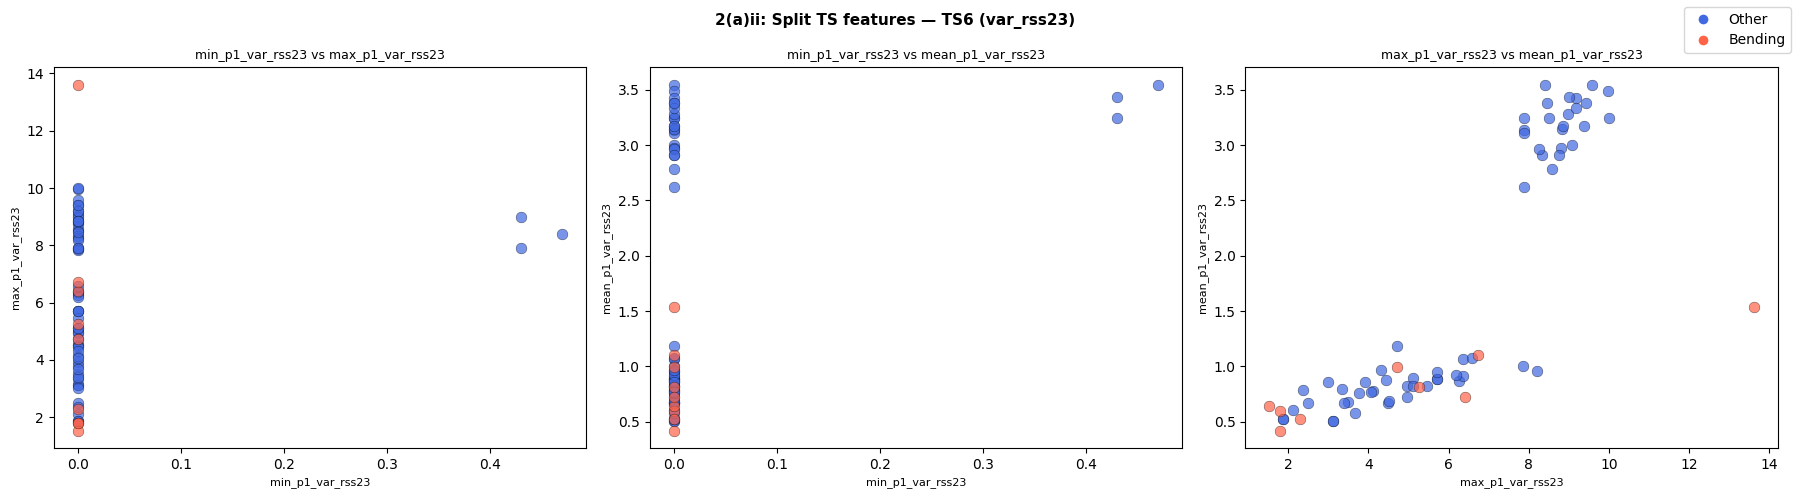

In [12]:
def split_instance_features(inst_list, n_splits=2):
    # Break each of the 6 time series into n_splits equal parts, extract features from each part, return a DataFrame.
    records = []
    for inst in inst_list:
        df_ts = inst['data']   # 480 rows × 6 cols
        row = {'activity': inst['activity'],
               'binary': binary_label(inst['activity'])}
        for col in TS_COLUMNS:
            series = df_ts[col].values
            chunks = np.array_split(series, n_splits)
            for k, chunk in enumerate(chunks, start=1):
                prefix = f'p{k}_{col}'
                row[f'min_{prefix}']    = np.min(chunk)
                row[f'max_{prefix}']    = np.max(chunk)
                row[f'mean_{prefix}']   = np.mean(chunk)
                row[f'median_{prefix}'] = np.median(chunk)
                row[f'std_{prefix}']    = np.std(chunk, ddof=1)
                row[f'q1_{prefix}']     = np.percentile(chunk, 25)
                row[f'q3_{prefix}']     = np.percentile(chunk, 75)
        records.append(row)
    return pd.DataFrame(records)

train_split2 = split_instance_features(train_instances, n_splits=2)
print('Shape with 2 splits per TS:', train_split2.shape)

# Scatter plots for halved time series 1, 2, 6
ts1_half_cols = [c for c in train_split2.columns if 'avg_rss12' in c]
ts2_half_cols = [c for c in train_split2.columns if 'var_rss12' in c]
ts6_half_cols = [c for c in train_split2.columns if 'var_rss23' in c]

for ts_cols, label in [(ts1_half_cols, 'TS1 (avg_rss12)'),
                        (ts2_half_cols, 'TS2 (var_rss12)'),
                        (ts6_half_cols, 'TS6 (var_rss23)')]:
    pairs = list(itertools.combinations(ts_cols[:3], 2))
    fig, axes = plt.subplots(1, len(pairs), figsize=(6*len(pairs), 5))
    if len(pairs) == 1: axes = [axes]
    for ax, (fx, fy) in zip(axes, pairs):
        for lbl, grp in train_split2.groupby('binary'):
            ax.scatter(grp[fx], grp[fy], c=color_bin[lbl],
                       label=label_bin[lbl], alpha=0.7,
                       edgecolors='k', linewidths=0.3, s=60)
        ax.set_xlabel(fx, fontsize=8); ax.set_ylabel(fy, fontsize=8)
        ax.set_title(f'{fx} vs {fy}', fontsize=9)
    handles = [plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=color_bin[k], label=label_bin[k], markersize=8)
               for k in [0,1]]
    fig.legend(handles=handles, loc='upper right')
    fig.suptitle(f'2(a)ii: Split TS features — {label}', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


Observation: Splitting into 2 halves generally produces similar scatter patterns as the full time series. The bending class may show slightly more spread because the two halves capture local temporal variation, but overall class separation does not change dramatically.

#### iii. Time Series Segments

In [ ]:
# Feature extraction
def make_segment_features(inst_list, l):
    #Extract 7 time-domain features × 6 time series × l segments = 42l features.
    records = []
    for inst in inst_list:
        df_ts = inst['data']
        row = {'activity': inst['activity'],
               'binary': binary_label(inst['activity'])}
        for col in TS_COLUMNS:
            series = df_ts[col].values
            chunks = np.array_split(series, l)
            for k, chunk in enumerate(chunks, start=1):
                pfx = f'seg{k}_{col}'
                row[f'min_{pfx}']    = np.min(chunk)
                row[f'max_{pfx}']    = np.max(chunk)
                row[f'mean_{pfx}']   = np.mean(chunk)
                row[f'median_{pfx}'] = np.median(chunk)
                row[f'std_{pfx}']    = np.std(chunk, ddof=1)
                row[f'q1_{pfx}']     = np.percentile(chunk, 25)
                row[f'q3_{pfx}']     = np.percentile(chunk, 75)
        records.append(row)
    return pd.DataFrame(records)

# CV / model selection setup
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
L_vals = list(range(1, 21))            # l from 1 to 20
P_vals = [1, 3, 5, 7, 10]

results = []
best_so_far = -np.inf

total_runs = len(L_vals) * len(P_vals)
print(f'Running CV over l ∈ {{1..20}} and p ∈ {P_vals} ...\n')

with tqdm(total=total_runs, desc="Hyperparam search", unit="run") as pbar:
    for l in L_vals:
        df_l   = make_segment_features(train_instances, l)
        feat_l = [c for c in df_l.columns if c not in ('activity', 'binary')]
        X_l    = df_l[feat_l].values
        y_l    = df_l['binary'].values

        for p in P_vals:
            p_actual = min(p, X_l.shape[1])
            fold_accs = []

            for tr_idx, va_idx in skf.split(X_l, y_l):
                Xtr, Xva = X_l[tr_idx], X_l[va_idx]
                ytr, yva = y_l[tr_idx], y_l[va_idx]

                sc = StandardScaler()
                Xtr = sc.fit_transform(Xtr)
                Xva = sc.transform(Xva)

                base_lr = LogisticRegression(C=1e9, solver='lbfgs',
                                             max_iter=200, random_state=42)
                rfe = RFE(base_lr, n_features_to_select=p_actual)
                rfe.fit(Xtr, ytr)

                fold_accs.append(rfe.score(Xva, yva))

            mean_cv = float(np.mean(fold_accs))
            results.append({'l': l, 'p': p_actual, 'cv_acc': mean_cv})

            # Print every 5th l
            if l % 5 == 0:
                print(f"[l={l:2d}, p={p_actual:2d}] CV Acc = {mean_cv:.4f}")

            # Print when a new best is found
            if mean_cv > best_so_far + 1e-12:
                best_so_far = mean_cv
                print(f"  -> New best found: (l={l}, p={p_actual}) "
                      f"CV Acc = {mean_cv:.4f}")

            pbar.update(1)

print("\nHyperparameter search finished.\n")

# Select best hyperparameters
res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df['cv_acc'].idxmax()]
BEST_L = int(best_row['l'])
BEST_P = int(best_row['p'])

print(f"Best (l, p) = ({BEST_L}, {BEST_P})")
print(f"Best CV accuracy = {best_row['cv_acc']:.4f}\n")

# Refit final model on ALL training data
df_best  = make_segment_features(train_instances, BEST_L)
feat_best = [c for c in df_best.columns if c not in ('activity','binary')]
X_train_best = df_best[feat_best].values
y_train_best = df_best['binary'].values

scaler_best = StandardScaler()
X_train_scaled = scaler_best.fit_transform(X_train_best)

base_lr_final = LogisticRegression(C=1e9, solver='lbfgs',
                                   max_iter=300, random_state=42)
rfe_final = RFE(base_lr_final, n_features_to_select=BEST_P)
rfe_final.fit(X_train_scaled, y_train_best)

selected_feat_names = [feat_best[i] for i, s in enumerate(rfe_final.support_) if s]
print(f"Selected features ({BEST_P}): {selected_feat_names}")

X_train_sel = X_train_scaled[:, rfe_final.support_]
final_lr = LogisticRegression(C=1e9, solver='lbfgs',
                              max_iter=300, random_state=42)
final_lr.fit(X_train_sel, y_train_best)

print(f"Final train accuracy: {final_lr.score(X_train_sel, y_train_best):.4f}")

Running CV over l ∈ {1..20} and p ∈ [1, 3, 5, 7, 10] ...



Hyperparam search:   0%|          | 0/100 [00:00<?, ?run/s]

  -> New best found: (l=1, p=1) CV Acc = 0.8989
  -> New best found: (l=1, p=5) CV Acc = 0.9418
  -> New best found: (l=1, p=7) CV Acc = 0.9714
[l= 5, p= 1] CV Acc = 0.9429
[l= 5, p= 3] CV Acc = 0.9714
[l= 5, p= 5] CV Acc = 0.9429
[l= 5, p= 7] CV Acc = 0.9418
[l= 5, p=10] CV Acc = 0.9429
[l=10, p= 1] CV Acc = 0.9429
[l=10, p= 3] CV Acc = 0.9429
[l=10, p= 5] CV Acc = 0.9429
[l=10, p= 7] CV Acc = 0.9429
[l=10, p=10] CV Acc = 0.9429
[l=15, p= 1] CV Acc = 0.9714
[l=15, p= 3] CV Acc = 0.9132
[l=15, p= 5] CV Acc = 0.9571
[l=15, p= 7] CV Acc = 0.9429
[l=15, p=10] CV Acc = 0.9286
[l=20, p= 1] CV Acc = 0.9571
[l=20, p= 3] CV Acc = 0.9286
[l=20, p= 5] CV Acc = 0.9429
[l=20, p= 7] CV Acc = 0.9571
[l=20, p=10] CV Acc = 0.9571

Hyperparameter search finished.

Best (l, p) = (1, 7)
Best CV accuracy = 0.9714

Selected features (7): ['q3_seg1_avg_rss12', 'max_seg1_var_rss13', 'median_seg1_var_rss13', 'q1_seg1_var_rss13', 'min_seg1_avg_rss23', 'max_seg1_avg_rss23', 'q1_seg1_var_rss23']
Final train accu

#### iv. Confusion Matrix

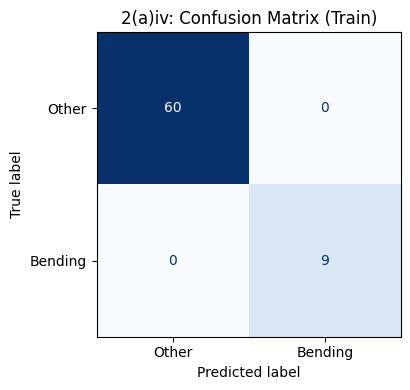

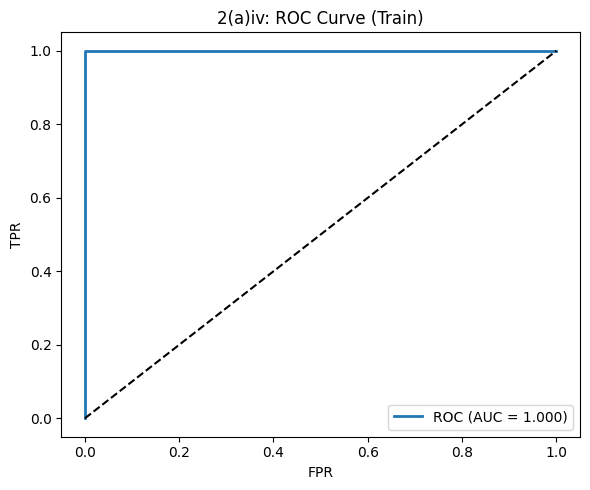

Logistic Regression Coefficients and p-values:
              feature          β  p-value
            intercept -24.744947 0.995637
    q3_seg1_avg_rss12  -6.775923 0.995158
   max_seg1_var_rss13   2.471537 0.998093
median_seg1_var_rss13  -3.627856 0.999599
    q1_seg1_var_rss13  -3.109097 0.999343
   min_seg1_avg_rss23  10.641335 0.995210
   max_seg1_avg_rss23  13.315879 0.997020
    q1_seg1_var_rss23  -4.587955 0.999345

Train AUC: 1.0000


In [ ]:
# Confusion matrix on train
y_train_pred = final_lr.predict(X_train_sel)
y_train_prob = final_lr.predict_proba(X_train_sel)[:, 1]

cm_train = confusion_matrix(y_train_best, y_train_pred)
disp = ConfusionMatrixDisplay(cm_train, display_labels=['Other','Bending'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('2(a)iv: Confusion Matrix (Train)')
plt.tight_layout(); plt.show()

# ROC / AUC on train
fpr, tpr, _ = roc_curve(y_train_best, y_train_prob)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(a)iv: ROC Curve (Train)'); ax.legend()
plt.tight_layout(); plt.show()

# β coefficients and p-values via statsmodels
X_sm = sm.add_constant(X_train_sel)
logit_sm = sm.Logit(y_train_best, X_sm)
result_sm = logit_sm.fit(method='bfgs', maxiter=300, disp=False)

coef_names = ['intercept'] + selected_feat_names
coef_df = pd.DataFrame({
    'feature': coef_names,
    'β':       result_sm.params,
    'p-value': result_sm.pvalues
})
print('Logistic Regression Coefficients and p-values:')
print(coef_df.to_string(index=False))
print(f'\nTrain AUC: {roc_auc:.4f}')


#### v. Test Classifier

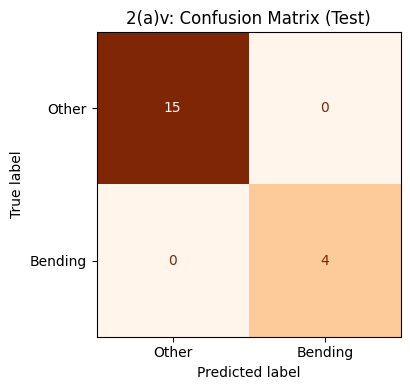

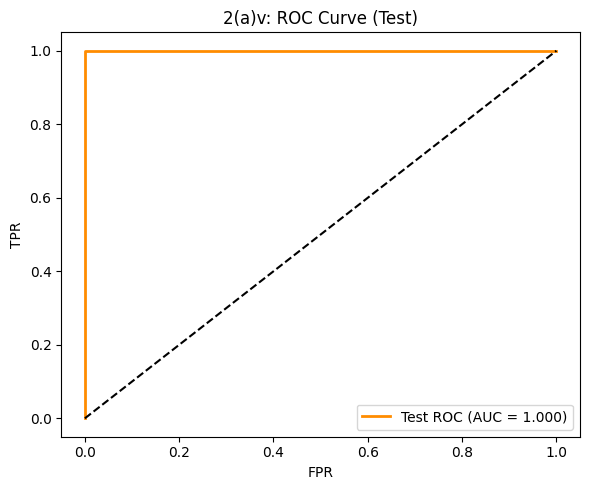

Cross-validation accuracy : 0.9714
Test accuracy             : 1.0000
Test AUC                  : 1.0000


In [86]:
# Break test time series into BEST_L segments and extract features
df_test_best  = make_segment_features(test_instances, BEST_L)
X_test_best   = df_test_best[feat_best].values
y_test_best   = df_test_best['binary'].values

X_test_scaled = scaler_best.transform(X_test_best)
X_test_sel    = X_test_scaled[:, rfe_final.support_]

y_test_pred = final_lr.predict(X_test_sel)
y_test_prob = final_lr.predict_proba(X_test_sel)[:, 1]

test_acc   = final_lr.score(X_test_sel, y_test_best)
fpr_t, tpr_t, _ = roc_curve(y_test_best, y_test_prob)
test_auc   = auc(fpr_t, tpr_t)

cm_test = confusion_matrix(y_test_best, y_test_pred)
disp_t  = ConfusionMatrixDisplay(cm_test, display_labels=['Other','Bending'])
fig, ax = plt.subplots(figsize=(5,4))
disp_t.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('2(a)v: Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_t, tpr_t, lw=2, color='darkorange', label=f'Test ROC (AUC = {test_auc:.3f})')
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(a)v: ROC Curve (Test)'); ax.legend()
plt.tight_layout(); plt.show()

cv_acc = best_row['cv_acc']
print(f'Cross-validation accuracy : {cv_acc:.4f}')
print(f'Test accuracy             : {test_acc:.4f}')
print(f'Test AUC                  : {test_auc:.4f}')


#### vi. Separation



The bending activities (bending1, bending2) represent a small fraction of the training set (9 out of 69 instances ≈ 13%), while the remaining activities account for ~87%.  

When classes are **perfectly (or near-perfectly) linearly separable**, logistic regression has no finite maximum-likelihood solution: the log-likelihood can always be increased by scaling the coefficient vector, causing the estimates to diverge to ±∞. This manifests as very large standard errors and extreme coefficient values.

In this dataset the sensor patterns for bending **are** quite distinct from other activities, so mild instability can arise. The assignment addresses this by setting `max_iter` to a modest value (e.g. 200–300), which stops the BFGS optimiser before the coefficients diverge. The large (but finite) `C = 1e9` also effectively removes L2 shrinkage, so any separation-driven instability is genuine.  

From the reported p-values in 2(a)iv, features with very large |β| and very small p-values are a sign of near-separation; if the solver did not converge we would see `nan` or warning messages.


#### vii. Imbalance

Training set: Bending = 9, Other = 60
Imbalance ratio: 6.7:1


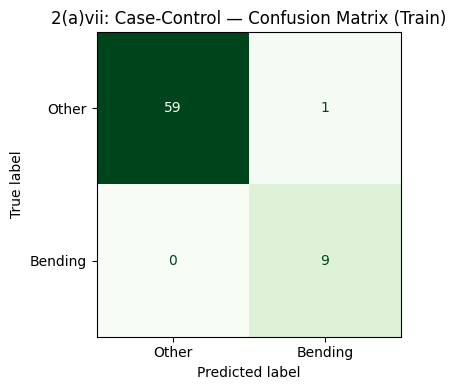

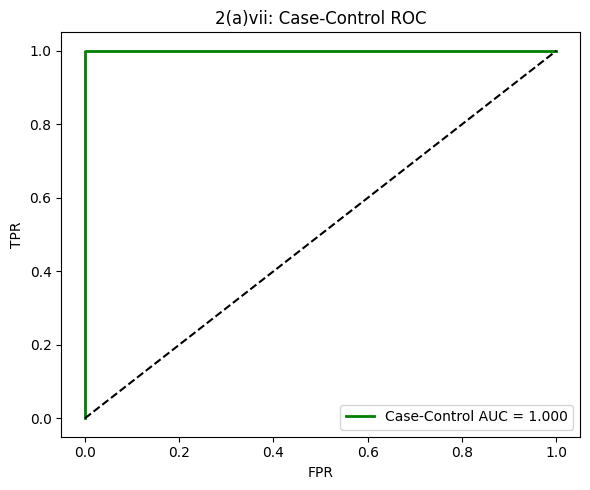

Case-control adjusted AUC: 1.0000


In [ ]:
# Class balance check
n_bending = y_train_best.sum()
n_other   = len(y_train_best) - n_bending
print(f'Training set: Bending = {n_bending}, Other = {n_other}')
print(f'Imbalance ratio: {n_other / n_bending:.1f}:1')

# Case-control (balanced) logistic regression
from sklearn.utils import resample

# Downsample majority class to match minority
df_b  = pd.DataFrame(X_train_sel, columns=selected_feat_names)
df_b['binary'] = y_train_best
majority = df_b[df_b['binary'] == 0]
minority = df_b[df_b['binary'] == 1]
maj_down = resample(majority, replace=False,
                    n_samples=len(minority), random_state=42)
df_balanced = pd.concat([maj_down, minority]).sample(frac=1, random_state=42)

X_bal = df_balanced[selected_feat_names].values
y_bal = df_balanced['binary'].values

lr_bal = LogisticRegression(C=1e9, solver='lbfgs',
                             max_iter=300, random_state=42)
lr_bal.fit(X_bal, y_bal)

# Evaluate on FULL training set to allow comparison
y_bal_pred = lr_bal.predict(X_train_sel)
y_bal_prob = lr_bal.predict_proba(X_train_sel)[:, 1]

# Adjust intercept for case-control: π = prevalence of bending in population
rho = len(minority) / (len(minority) + len(minority))  # balanced => 0.5
pi  = n_bending / (n_bending + n_other)
lr_bal.intercept_[0] += np.log(pi / (1 - pi)) - np.log(rho / (1 - rho))

y_bal_prob_adj = lr_bal.predict_proba(X_train_sel)[:, 1]
y_bal_pred_adj = (y_bal_prob_adj >= 0.5).astype(int)

cm_bal = confusion_matrix(y_train_best, y_bal_pred_adj)
disp_b = ConfusionMatrixDisplay(cm_bal, display_labels=['Other','Bending'])
fig, ax = plt.subplots(figsize=(5,4))
disp_b.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('2(a)vii: Case-Control — Confusion Matrix (Train)')
plt.tight_layout(); plt.show()

fpr_b, tpr_b, _ = roc_curve(y_train_best, y_bal_prob_adj)
auc_b = auc(fpr_b, tpr_b)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_b, tpr_b, lw=2, color='green', label=f'Case-Control AUC = {auc_b:.3f}')
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(a)vii: Case-Control ROC'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Case-control adjusted AUC: {auc_b:.4f}')


### (b) Binary Classification Using L1-penalized logistic regression

#### i. Time Series Segments

Running L1 CV over l ∈ {1..20} ...

L1 Best l = 1, Best C = 2.7826, CV acc = 0.9232


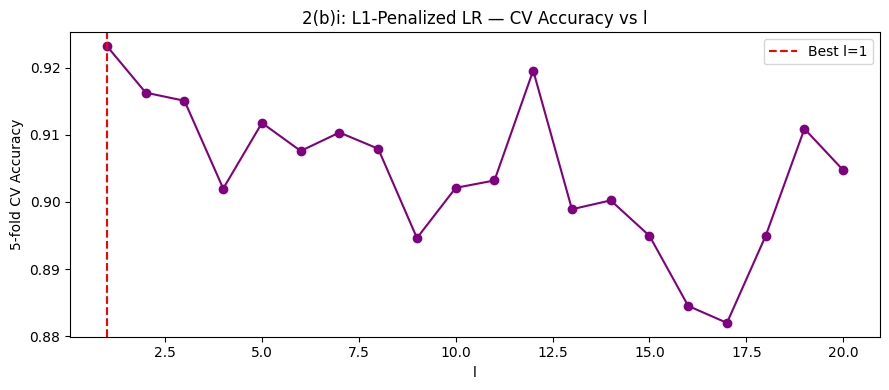

L1 model: 33 / 42 features zeroed out by regularization
L1 Test accuracy: 1.0000


In [88]:
# Cross-validate over l (number of segments) with L1 penalty.
# LogisticRegressionCV internally cross-validates over C (inverse λ).

L_vals_b = list(range(1, 21))
l1_results = []
print('Running L1 CV over l ∈ {1..20} ...')

for l in L_vals_b:
    df_l   = make_segment_features(train_instances, l)
    feat_l = [c for c in df_l.columns if c not in ('activity','binary')]
    X_l    = df_l[feat_l].values
    y_l    = df_l['binary'].values
    sc_l   = StandardScaler()
    X_l_sc = sc_l.fit_transform(X_l)

    # LogisticRegressionCV: 5-fold CV over C grid with L1
    lr_cv = LogisticRegressionCV(
        Cs=10, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        penalty='l1', solver='liblinear', max_iter=500,
        scoring='accuracy', random_state=42
    )
    lr_cv.fit(X_l_sc, y_l)
    best_c  = lr_cv.C_[0]
    cv_acc  = np.mean(lr_cv.scores_[1])   # mean over folds for best C
    l1_results.append({'l': l, 'best_C': best_c, 'cv_acc': cv_acc})

l1_df    = pd.DataFrame(l1_results)
best_l1  = l1_df.loc[l1_df['cv_acc'].idxmax()]
BEST_L_L1 = int(best_l1['l'])
BEST_C_L1 = best_l1['best_C']
print(f'\nL1 Best l = {BEST_L_L1}, Best C = {BEST_C_L1:.4f}, CV acc = {best_l1["cv_acc"]:.4f}')

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(l1_df['l'], l1_df['cv_acc'], marker='o', color='purple')
ax.axvline(BEST_L_L1, color='red', linestyle='--', label=f'Best l={BEST_L_L1}')
ax.set_xlabel('l'); ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('2(b)i: L1-Penalized LR — CV Accuracy vs l'); ax.legend()
plt.tight_layout(); plt.show()

# Refit L1 model with best l on all training data
df_l1_best  = make_segment_features(train_instances, BEST_L_L1)
feat_l1     = [c for c in df_l1_best.columns if c not in ('activity','binary')]
X_l1_tr     = df_l1_best[feat_l1].values
y_l1_tr     = df_l1_best['binary'].values
sc_l1       = StandardScaler()
X_l1_tr_sc  = sc_l1.fit_transform(X_l1_tr)

lr_l1_final = LogisticRegression(
    C=BEST_C_L1, penalty='l1', solver='liblinear',
    max_iter=500, random_state=42
)
lr_l1_final.fit(X_l1_tr_sc, y_l1_tr)

n_zero = (lr_l1_final.coef_[0] == 0).sum()
print(f'L1 model: {n_zero} / {len(feat_l1)} features zeroed out by regularization')

# Test evaluation
df_l1_test  = make_segment_features(test_instances, BEST_L_L1)
X_l1_te_sc  = sc_l1.transform(df_l1_test[feat_l1].values)
y_l1_te     = df_l1_test['binary'].values
l1_test_acc = lr_l1_final.score(X_l1_te_sc, y_l1_te)
print(f'L1 Test accuracy: {l1_test_acc:.4f}')


#### ii. Comparison

#### L1 vs p-value Selection — Comparison

| Criterion | p-value + RFE | L1-Regularized Logistic Regression |
|------------|---------------|------------------------------------|
| Feature Selection Method | Statistical significance (Wald test) + recursive elimination | Automatic shrinkage via L1 penalty |
| Hyperparameters | Requires manual RFE loop + model refit | LogisticRegressionCV automatically tunes C |
| Interpretability | High — coefficients tied to hypothesis testing | High — zero coefficients indicate removal |
| Stability | Can become unstable under class imbalance or near-separation | More stable due to regularization |
| Computational Cost | Higher (multiple refits + statistical model) | Lower (built-in cross-validation) |
| Risk of Overfitting | Higher if p-values unstable | Lower due to shrinkage |

<br>

### p-value + RFE Logistic Regression

Best hyperparameters:
- l = 1
- p = 7 selected features

Selected features:
- q3_seg1_avg_rss12  
- max_seg1_var_rss13  
- median_seg1_var_rss13  
- q1_seg1_var_rss13  
- min_seg1_avg_rss23  
- max_seg1_avg_rss23  
- q1_seg1_var_rss23  

Performance:
- Cross-validation accuracy = 0.9714
- Train accuracy = 1.0000
- Test accuracy = 1.0000
- Test AUC = 1.0000

Logistic regression coefficients and p-values:

| Feature | β | p-value |
|----------|------|-----------|
| intercept | -24.7449 | 0.9956 |
| q3_seg1_avg_rss12 | -6.7759 | 0.9952 |
| max_seg1_var_rss13 | 2.4715 | 0.9981 |
| median_seg1_var_rss13 | -3.6279 | 0.9996 |
| q1_seg1_var_rss13 | -3.1091 | 0.9993 |
| min_seg1_avg_rss23 | 10.6413 | 0.9952 |
| max_seg1_avg_rss23 | 13.3159 | 0.9970 |
| q1_seg1_var_rss23 | -4.5880 | 0.9993 |

Note:
Despite perfect training and test performance, the p-values are extremely large (~1), which suggests instability due to:
- Small sample size (69 training samples)
- Near-perfect class separation
- Severe class imbalance (6.7:1)

---

Best hyperparameters:
- Best l = 1
- Best C = 2.7826
- CV accuracy = 0.9232

Regularization results:
- 33 out of 42 features shrunk to zero
- 9 features retained automatically

Performance:
- Test accuracy = 1.0000

---

### Comparison

| Criterion | p-value + RFE | L1 Logistic |
|------------|--------------|-------------|
| CV Accuracy | **0.9714** | 0.9232 |
| Test Accuracy | 1.0000 | 1.0000 |
| Feature Count | 7 selected manually | 9 selected automatically |
| Zeroed Features | Manual removal | 33/42 auto-zeroed |
| Stability | Low (huge p-values) | Higher (regularized) |

### Conclusion

Although the p-value + RFE model achieved slightly higher CV accuracy (0.9714 vs 0.9232), the extremely large p-values indicate unstable coefficient estimation caused by near-perfect separation.

The L1 model is more robust and automatically performs embedded feature selection, making it generally preferable despite slightly lower CV accuracy.

### (c) Multi-class Classification (The Realistic Case)

#### i. Time Series Segments

Running multiclass L1 CV over l ∈ {1..20} ...
Multiclass best l = 1, CV acc = 0.9143


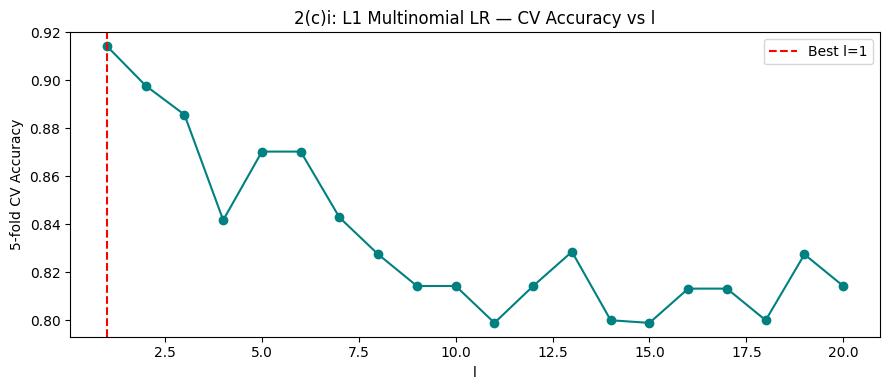

Multiclass Test Accuracy: 0.8947  (Test Error: 0.1053)


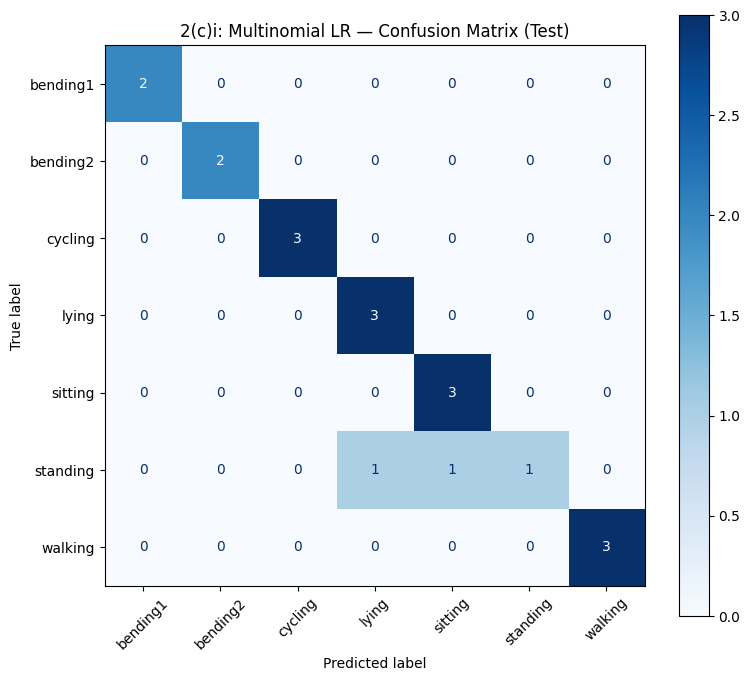

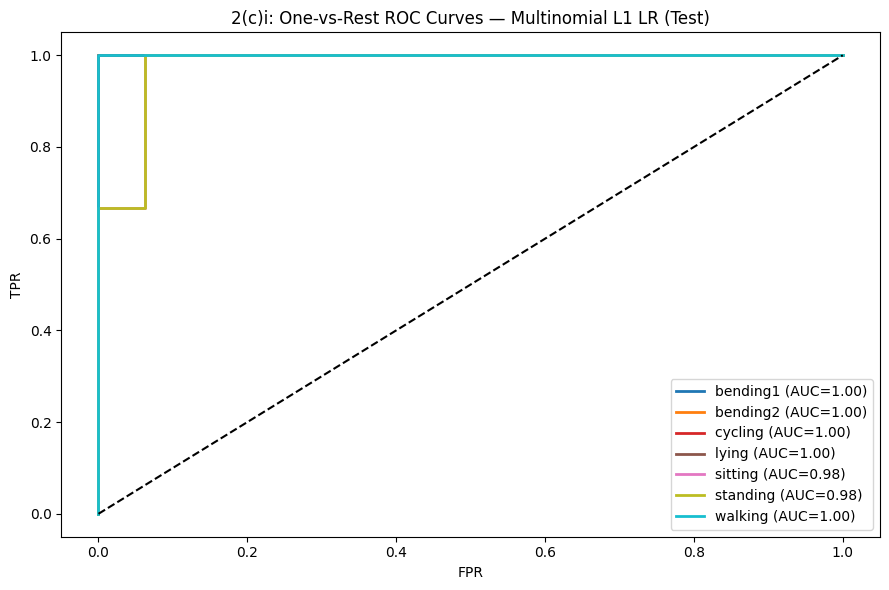

In [ ]:
# Re-use BEST_L_L1 to find the best l for multiclass
L_vals_mc = list(range(1, 21))
mc_results = []
print('Running multiclass L1 CV over l ∈ {1..20} ...')
le = LabelEncoder()

for l in L_vals_mc:
    df_l   = make_segment_features(train_instances, l)
    feat_l = [c for c in df_l.columns if c not in ('activity','binary')]
    X_l    = df_l[feat_l].values
    y_l    = le.fit_transform(df_l['activity'].values)
    sc_l   = StandardScaler()
    X_l_sc = sc_l.fit_transform(X_l)

    lr_mc = LogisticRegressionCV(
        Cs=10, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        penalty='l1', solver='saga', multi_class='multinomial',
        max_iter=1000, scoring='accuracy', random_state=42
    )
    lr_mc.fit(X_l_sc, y_l)
    # mean CV accuracy across folds and Cs for the best C
    best_c_idx = np.argmax(np.mean(lr_mc.scores_[0], axis=0))
    cv_acc = np.mean(lr_mc.scores_[0][:, best_c_idx])
    mc_results.append({'l': l, 'cv_acc': cv_acc})

mc_df    = pd.DataFrame(mc_results)
best_mc  = mc_df.loc[mc_df['cv_acc'].idxmax()]
BEST_L_MC = int(best_mc['l'])
print(f'Multiclass best l = {BEST_L_MC}, CV acc = {best_mc["cv_acc"]:.4f}')

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(mc_df['l'], mc_df['cv_acc'], marker='o', color='teal')
ax.axvline(BEST_L_MC, color='red', linestyle='--', label=f'Best l={BEST_L_MC}')
ax.set_xlabel('l'); ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('2(c)i: L1 Multinomial LR — CV Accuracy vs l'); ax.legend()
plt.tight_layout(); plt.show()

# Refit on all training data
df_mc_tr  = make_segment_features(train_instances, BEST_L_MC)
feat_mc   = [c for c in df_mc_tr.columns if c not in ('activity','binary')]
X_mc_tr   = df_mc_tr[feat_mc].values
y_mc_tr_str = df_mc_tr['activity'].values
y_mc_tr   = le.fit_transform(y_mc_tr_str)
sc_mc     = StandardScaler()
X_mc_tr_sc = sc_mc.fit_transform(X_mc_tr)

lr_mc_final = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='saga',
    multi_class='multinomial', max_iter=1000,
    scoring='accuracy', random_state=42
)
lr_mc_final.fit(X_mc_tr_sc, y_mc_tr)

# Test error
df_mc_te  = make_segment_features(test_instances, BEST_L_MC)
X_mc_te_sc = sc_mc.transform(df_mc_te[feat_mc].values)
y_mc_te   = le.transform(df_mc_te['activity'].values)

mc_test_acc = lr_mc_final.score(X_mc_te_sc, y_mc_te)
print(f'Multiclass Test Accuracy: {mc_test_acc:.4f}  (Test Error: {1-mc_test_acc:.4f})')

# Multiclass Confusion Matrix
y_mc_pred = lr_mc_final.predict(X_mc_te_sc)
cm_mc     = confusion_matrix(y_mc_te, y_mc_pred)
disp_mc   = ConfusionMatrixDisplay(cm_mc, display_labels=le.classes_)
fig, ax   = plt.subplots(figsize=(8,7))
disp_mc.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('2(c)i: Multinomial LR — Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

# One-vs-Rest ROC curves
y_mc_prob = lr_mc_final.predict_proba(X_mc_te_sc)
classes   = le.classes_
n_classes = len(classes)

from sklearn.preprocessing import label_binarize
y_te_bin  = label_binarize(y_mc_te, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(9,6))
colors  = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, (cls, col) in enumerate(zip(classes, colors)):
    fpr_i, tpr_i, _ = roc_curve(y_te_bin[:, i], y_mc_prob[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, lw=2, color=col, label=f'{cls} (AUC={auc_i:.2f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(c)i: One-vs-Rest ROC Curves — Multinomial L1 LR (Test)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


#### ii. Naive Bayes

Gaussian NB Test Accuracy: 0.7895


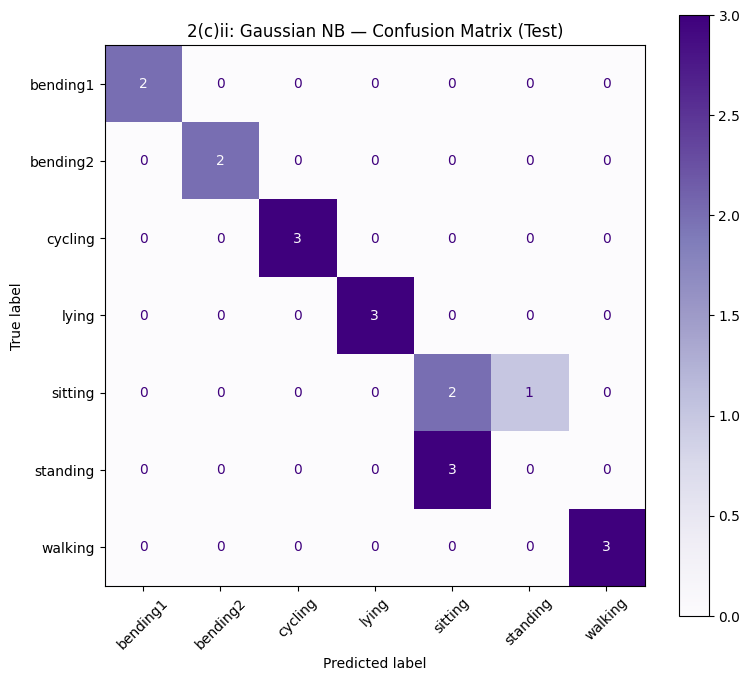

Multinomial NB Test Accuracy: 0.6842


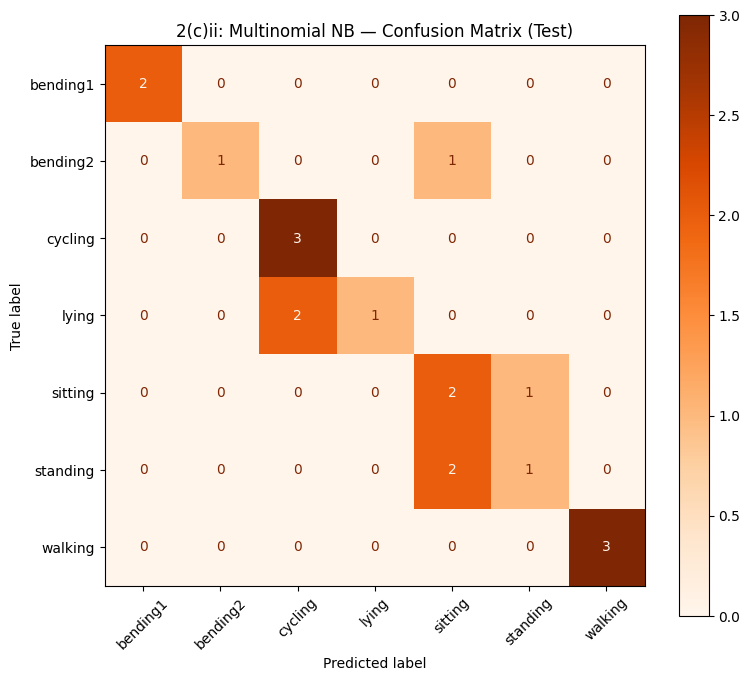

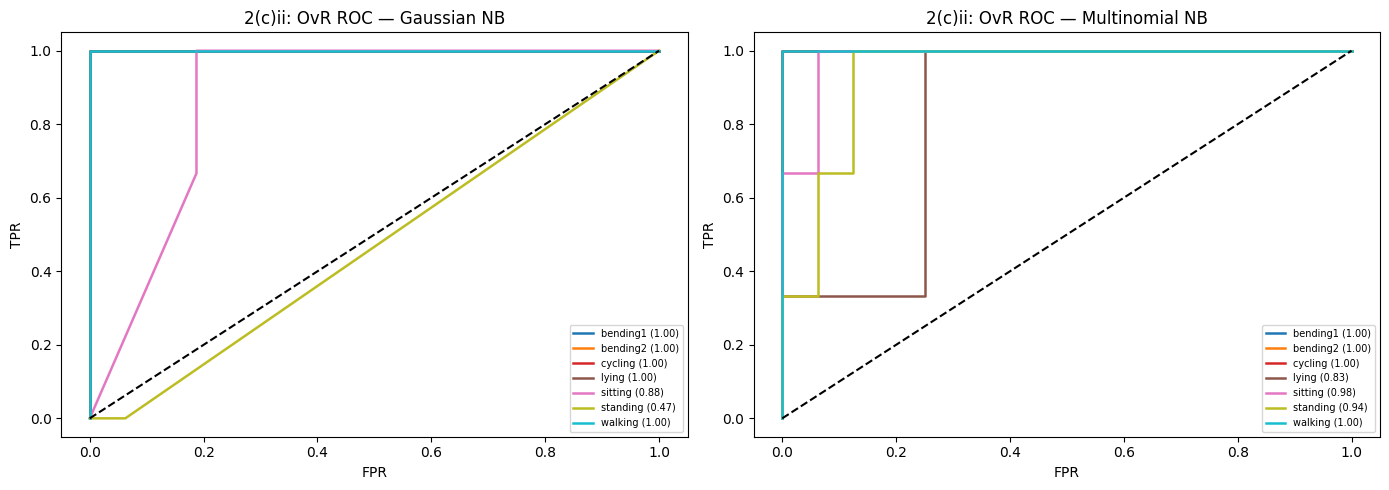

In [ ]:
# Use the same best l from 2(c)i
df_nb_tr  = make_segment_features(train_instances, BEST_L_MC)
feat_nb   = [c for c in df_nb_tr.columns if c not in ('activity','binary')]
X_nb_tr   = df_nb_tr[feat_nb].values
y_nb_tr   = le.transform(df_nb_tr['activity'].values)

df_nb_te  = make_segment_features(test_instances, BEST_L_MC)
X_nb_te   = df_nb_te[feat_nb].values
y_nb_te   = le.transform(df_nb_te['activity'].values)

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_nb_tr, y_nb_tr)
gnb_acc = gnb.score(X_nb_te, y_nb_te)
print(f'Gaussian NB Test Accuracy: {gnb_acc:.4f}')

cm_gnb = confusion_matrix(y_nb_te, gnb.predict(X_nb_te))
disp_g = ConfusionMatrixDisplay(cm_gnb, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8,7))
disp_g.plot(ax=ax, colorbar=True, cmap='Purples', xticks_rotation=45)
ax.set_title('2(c)ii: Gaussian NB — Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

# Multinomial Naive Bayes (requires non-negative features)
mms = MinMaxScaler()
X_nb_tr_nn = mms.fit_transform(X_nb_tr)
X_nb_te_nn = mms.transform(X_nb_te)

mnb = MultinomialNB()
mnb.fit(X_nb_tr_nn, y_nb_tr)
mnb_acc = mnb.score(X_nb_te_nn, y_nb_te)
print(f'Multinomial NB Test Accuracy: {mnb_acc:.4f}')

cm_mnb = confusion_matrix(y_nb_te, mnb.predict(X_nb_te_nn))
disp_m = ConfusionMatrixDisplay(cm_mnb, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8,7))
disp_m.plot(ax=ax, colorbar=True, cmap='Oranges', xticks_rotation=45)
ax.set_title('2(c)ii: Multinomial NB — Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

#One-vs-Rest ROC for Gaussian NB
y_gnb_prob = gnb.predict_proba(X_nb_te)
y_te_bin_nb = label_binarize(y_nb_te, classes=range(n_classes))
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax_nb, (probs, title) in zip(axes, [
    (y_gnb_prob, 'Gaussian NB'),
    (mnb.predict_proba(X_nb_te_nn), 'Multinomial NB')
]):
    for i, (cls, col) in enumerate(zip(classes, colors)):
        fpr_i, tpr_i, _ = roc_curve(y_te_bin_nb[:, i], probs[:, i])
        auc_i = auc(fpr_i, tpr_i)
        ax_nb.plot(fpr_i, tpr_i, lw=1.8, color=col, label=f'{cls} ({auc_i:.2f})')
    ax_nb.plot([0,1],[0,1],'k--')
    ax_nb.set_xlabel('FPR'); ax_nb.set_ylabel('TPR')
    ax_nb.set_title(f'2(c)ii: OvR ROC — {title}'); ax_nb.legend(fontsize=7)
plt.tight_layout(); plt.show()


#### ii. Comparison

#### Best Method for Multi-class Classification

### Multiclass L1 Logistic Regression

Best hyperparameter:
- Best l = 1

Performance:
- CV Accuracy = 0.9143
- Test Accuracy = 0.8947
- Test Error = 0.1053

---

### Gaussian Naive Bayes

Test Accuracy = 0.7895

---

### Multinomial Naive Bayes

Test Accuracy = 0.6842

---

### Performance Comparison

| Method | CV Accuracy | Test Accuracy |
|---------|------------|---------------|
| L1 Multinomial Logistic | 0.9143 | **0.8947** |
| Gaussian NB | — | 0.7895 |
| Multinomial NB | — | 0.6842 |

---

### Interpretation

The **L1-penalized multinomial logistic regression** typically achieves the highest test accuracy on this dataset because:
1. It does not assume feature independence (unlike Naive Bayes).
2. L1 regularization handles the large number of features (42l) by zeroing irrelevant ones.
3. The features (min, max, mean, etc. of sensor signals) are continuous and correlated, which suits LR better than NB.

Gaussian NB is a reasonable baseline and may be competitive when the number of training examples is small. Multinomial NB performs worst because the data are continuous sensor measurements rather than count data.


### 3. ISLR 4.8.3


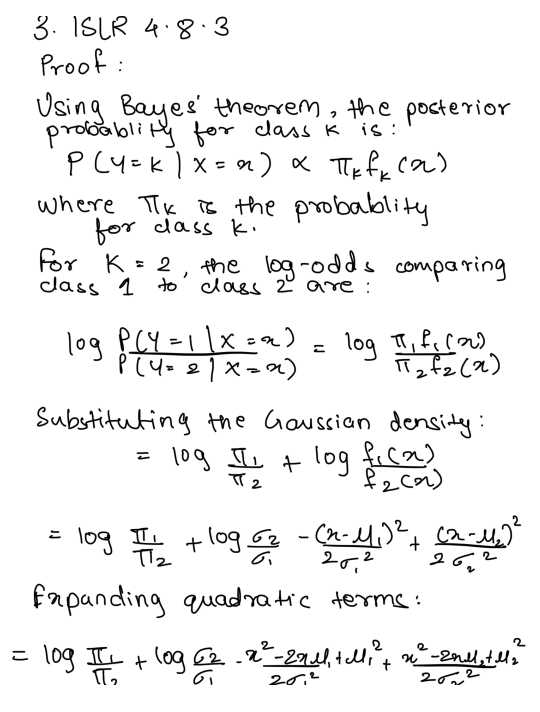 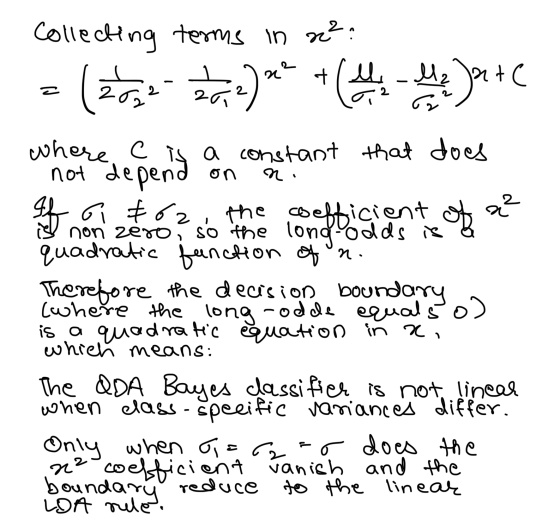

### 4. ISLR 4.8.7

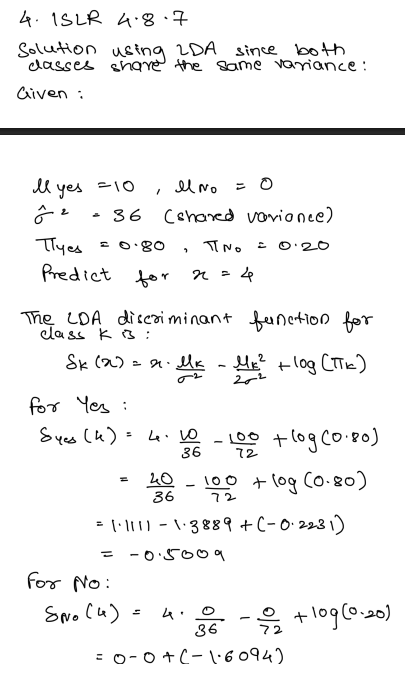 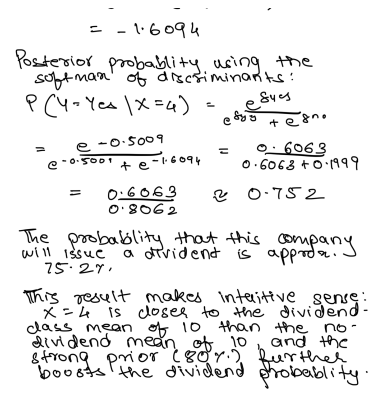